# **Module 03 Lab02: Exploratory Data Analysis - Laptop Pricing**

CISC7204 Assgn01 - Lab02 (Laptop Pricing) / Module 06 Final (House Pricing) | mc660725 Gao Si Han

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

In [2]:
df = pd.read_csv("laptop_mod2.csv", header=0)
df = df.drop(['Unnamed: 0','Unnamed: 0.1'], axis=1, errors='ignore')
df.head(5)

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


### Task 1 - Visualize individual feature patterns
Continuous features: regression plots of CPU_frequency, Screen_Size_inch, Weight_pounds against Price, plus correlation values.

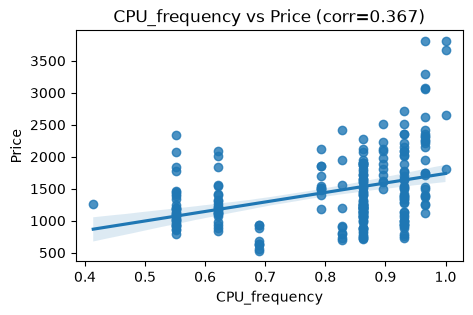

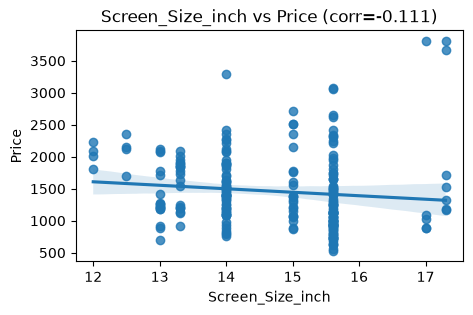

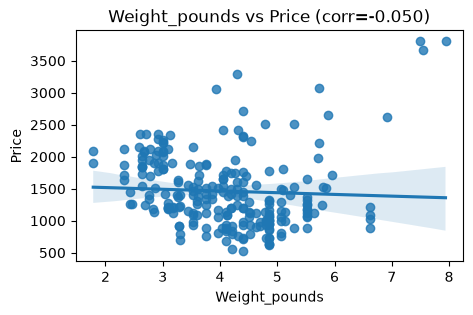

In [3]:
for col in ['CPU_frequency','Screen_Size_inch','Weight_pounds']:
    plt.figure(figsize=(5,3))
    sns.regplot(x=col, y='Price', data=df)
    plt.title(f'{col} vs Price (corr={df[col].corr(df["Price"]):.3f})')
    plt.show()

In [4]:
print("Correlation of continuous features with Price:")
for col in ['CPU_frequency','Screen_Size_inch','Weight_pounds']:
    print(f"  {col:16s}: {df[col].corr(df['Price']):.4f}")

Correlation of continuous features with Price:
  CPU_frequency   : 0.3667
  Screen_Size_inch: -0.1106
  Weight_pounds   : -0.0503


Categorical features: box plots for Category, GPU, OS, CPU_core, RAM_GB, Storage_GB_SSD vs Price.

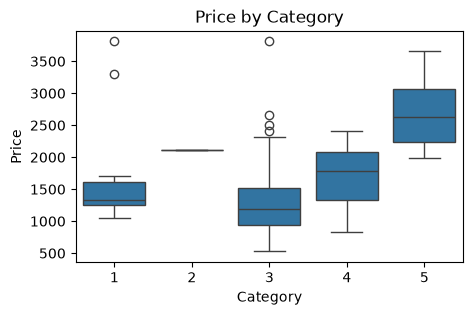

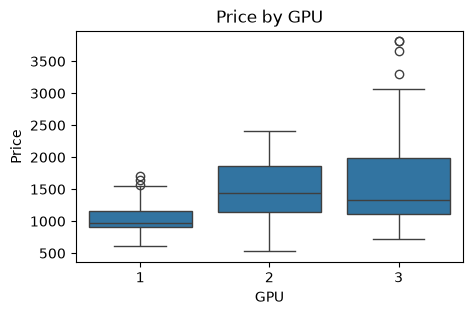

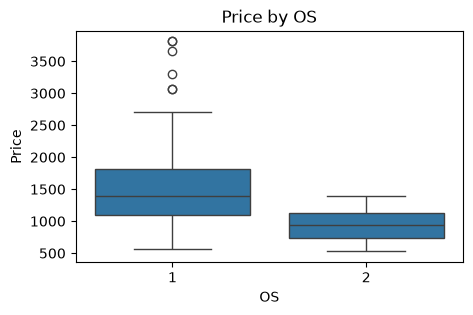

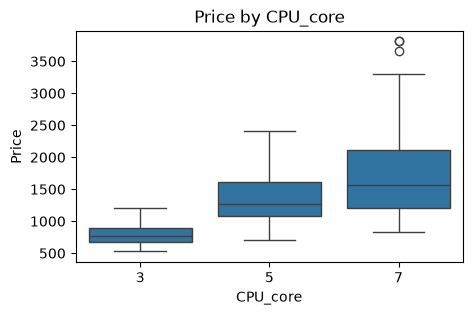

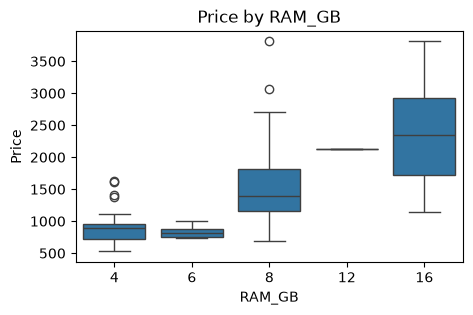

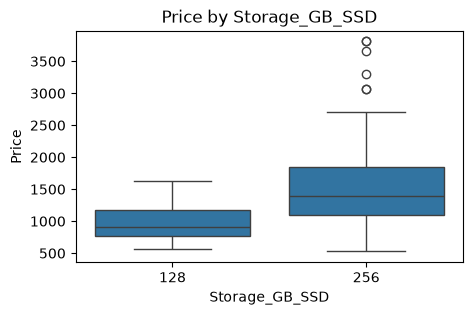

In [5]:
for col in ['Category','GPU','OS','CPU_core','RAM_GB','Storage_GB_SSD']:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=col, y='Price', data=df)
    plt.title(f'Price by {col}')
    plt.show()

### Task 2 - Descriptive Statistical Analysis

In [6]:
print(df.describe(include='all'))

       Manufacturer    Category         GPU          OS    CPU_core  \
count           238  238.000000  238.000000  238.000000  238.000000   
unique           11         NaN         NaN         NaN         NaN   
top            Dell         NaN         NaN         NaN         NaN   
freq             71         NaN         NaN         NaN         NaN   
mean            NaN    3.205882    2.151261    1.058824    5.630252   
std             NaN    0.776533    0.638282    0.235790    1.241787   
min             NaN    1.000000    1.000000    1.000000    3.000000   
25%             NaN    3.000000    2.000000    1.000000    5.000000   
50%             NaN    3.000000    2.000000    1.000000    5.000000   
75%             NaN    4.000000    3.000000    1.000000    7.000000   
max             NaN    5.000000    3.000000    2.000000    7.000000   

        Screen_Size_inch  CPU_frequency      RAM_GB  Storage_GB_SSD  \
count         238.000000     238.000000  238.000000      238.000000   
uniqu

### Task 3 - GroupBy and Pivot Table
Group GPU, CPU_core, Price into a pivot table and show with pcolor.

In [7]:
grouped_test1 = df[['GPU','CPU_core','Price']].groupby(['GPU','CPU_core'], as_index=False).mean()
grouped_test1

,GPU,CPU_core,Price
0,1,3,769.250000
1,1,5,998.500000
2,1,7,1167.941176
3,2,3,785.076923
4,2,5,1462.197674
5,2,7,1744.621622
6,3,3,784.000000
7,3,5,1220.680000
8,3,7,1945.097561


In [8]:
pivot = grouped_test1.pivot(index='GPU', columns='CPU_core', values='Price')
pivot

CPU_core,3,5,7
GPU,,,
1,769.250000,998.500000,1167.941176
2,785.076923,1462.197674,1744.621622
3,784.000000,1220.680000,1945.097561


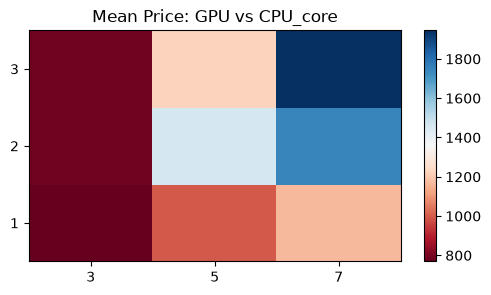

In [9]:
plt.figure(figsize=(6,3))
plt.pcolor(pivot, cmap='RdBu')
plt.colorbar()
plt.xticks(np.arange(0.5, len(pivot.columns), 1), pivot.columns)
plt.yticks(np.arange(0.5, len(pivot.index), 1), pivot.index)
plt.title('Mean Price: GPU vs CPU_core')
plt.show()

### Task 4 - Pearson Correlation and p-values for each attribute vs Price

In [10]:
from scipy.stats import pearsonr
print(f'{"Feature":16s} {"Pearson r":>10s} {"p-value":>12s}')
for col in ['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category','Screen_Size_inch','Weight_pounds']:
    r, p = pearsonr(df[col], df['Price'])
    print(f'{col:16s} {r:10.4f} {p:12.2e}')

Feature           Pearson r      p-value
CPU_frequency        0.3667     5.50e-09
RAM_GB               0.5493     3.68e-20
Storage_GB_SSD       0.2434     1.49e-04
CPU_core             0.4594     7.91e-14
OS                  -0.2217     5.70e-04
GPU                  0.2883     6.17e-06
Category             0.2862     7.23e-06
Screen_Size_inch    -0.1106     8.85e-02
Weight_pounds       -0.0503     4.40e-01


# Module 03 complete.